GULPS (Global Unitary Linear Programming Synthesis) compiles arbitrary two-qubit unitaries into non-standard instruction sets. It combines linear programming with lightweight numerics to handle fractional, continuous, or heterogeneous gate sets — anything beyond what analytical decomposition rules cover.

Define your instruction set as a list of `(gate, cost, name)` tuples where costs are additive.

In [1]:
from qiskit.circuit.library import iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary

from gulps import GulpsDecomposer

isa = [
    (iSwapGate().power(1.0), 1.0, "iswap"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

Pass any 4×4 unitary (Qiskit `Gate` or `np.ndarray`) and get back a `QuantumCircuit`.

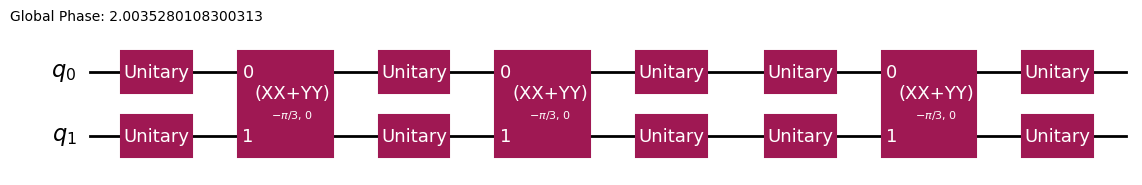

In [2]:
u = random_unitary(4, seed=0)
circuit = decomposer(u)
circuit.draw("mpl")

In [3]:
fid = average_gate_fidelity(u, Operator(circuit))
print(f"Fidelity: {fid:.12f}")

Fidelity: 0.999999999996


To compile a full multi-qubit circuit, use `GulpsDecompositionPass` as a Qiskit `TransformationPass`. GULPS leaves single-qubit gates unsimplified, so appending `Optimize1qGatesDecomposition` is recommended.

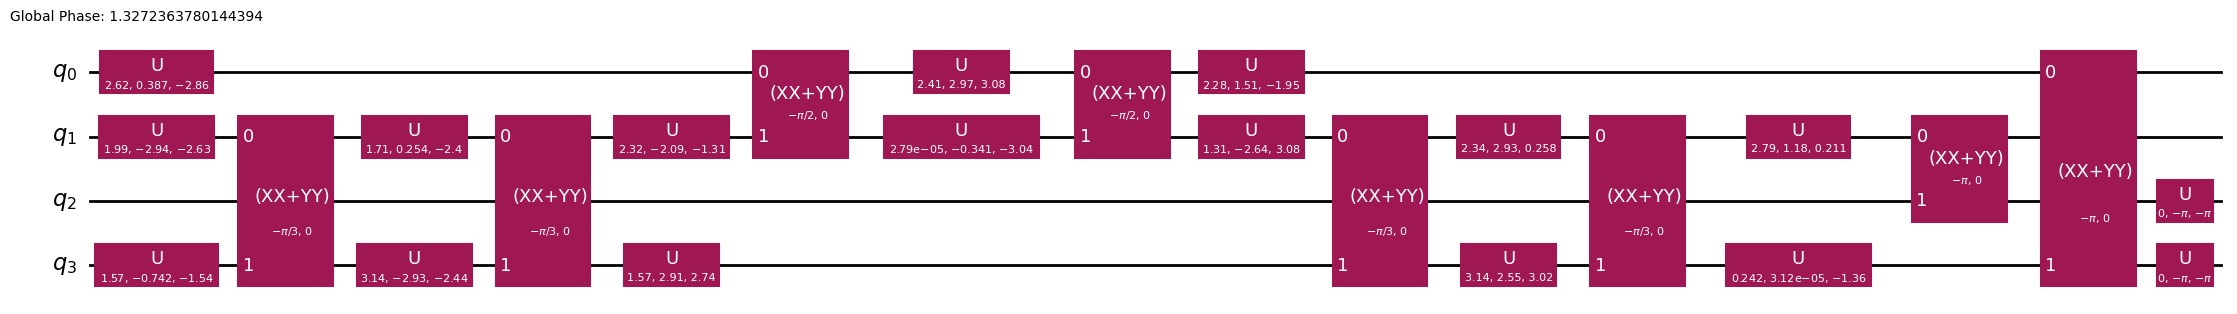

In [4]:
from gulps import GulpsDecompositionPass
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from qiskit.circuit.random import random_circuit

gulps_pm = PassManager(
    [
        GulpsDecompositionPass(decomposer),
        Optimize1qGatesDecomposition(basis="u3"),
    ]
)

input_qc = random_circuit(4, 4, max_operands=2, seed=0)
output_qc = gulps_pm.run(input_qc)
output_qc.draw("mpl", fold=-1)

GULPS also registers as a Qiskit transpiler plugin. If the instruction set is specified in a Qiskit `Target`, you can call `transpile()` directly.

In [5]:
from qiskit.transpiler.preset_passmanagers.plugin import list_stage_plugins

list_stage_plugins("translation")

['gulps', 'default', 'synthesis', 'translator']

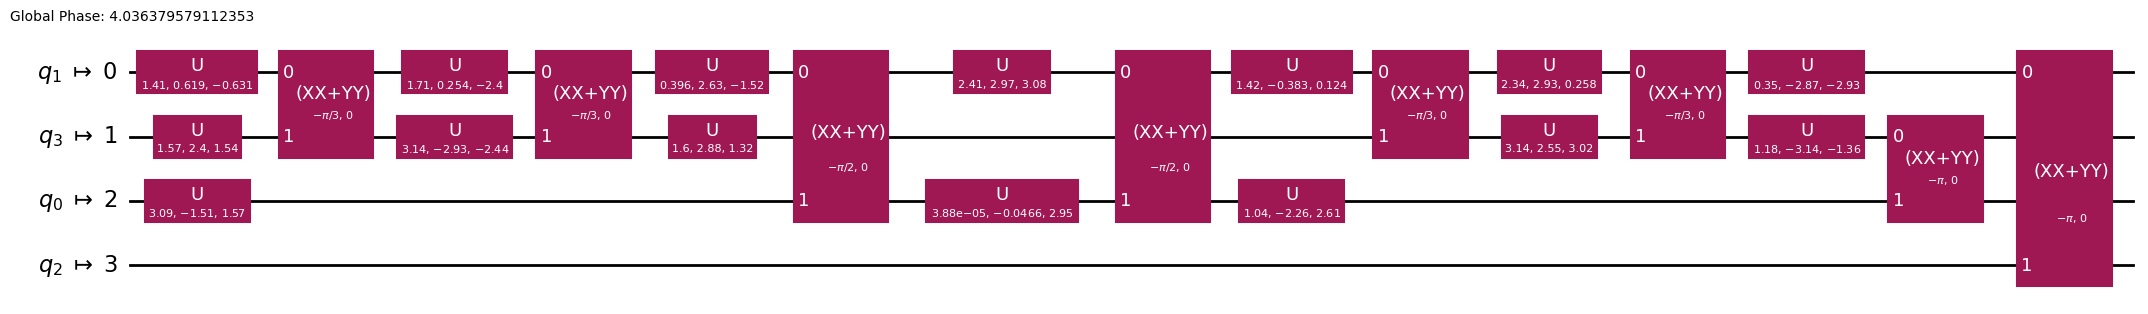

In [6]:
from qiskit import transpile
from gulps.isa_library.example_target import mock_iswap_family_target

output_qc = transpile(
    input_qc, target=mock_iswap_family_target, translation_method="gulps"
)
output_qc.draw("mpl", fold=-1)